In [1]:
!pip install sentence-transformers


[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [40]:
import pandas as pd

# Načtení registru lékařů
# Cesta musí směřovat tam, kde máš uložený ten vyčištěný CSV soubor z první fáze
# Pokud jsi ho uložil do složky data/processed, cesta bude vypadat takto:
try:
    df_registr = pd.read_csv('../data/processed/czech_registre_final.csv')
    print(f"Registr úspěšně načten! Počet záznamů: {len(df_registr)}")
except FileNotFoundError:
    print("Soubor nenalezen. Zkontroluj cestu k souboru czech_registre_final.csv.")

# Rychlá kontrola sloupců, aby AI věděla, s čím pracuje
print(df_registr.columns.tolist())

Registr úspěšně načten! Počet záznamů: 76321
['MistoPoskytovaniId', 'Ico', 'DruhZarizeni', 'NazevCely', 'Obec', 'Ulice', 'CisloDomovniOrientacni', 'Psc', 'Kraj', 'Okres', 'OborPece', 'GPS', 'PoskytovatelTelefon', 'PoskytovatelEmail', 'PoskytovatelWeb', 'RozsahPece', 'Adresa', 'OborPece_List']


C:\Users\honzi\AppData\Local\Temp\ipykernel_2844\2197201915.py:7: DtypeWarning: Columns (0: PoskytovatelTelefon) have mixed types. Specify dtype option on import or set low_memory=False.
  df_registr = pd.read_csv('../data/processed/czech_registre_final.csv')


In [3]:
# --- TATO ČÁST TI CHYBÍ V PAMĚTI ---
medical_mapping = {
    "Surgery": ["chirurgie", "dětská chirurgie", "cévní chirurgie", "traumatologie", "plastická chirurgie"],
    "Cardiovascular / Pulmonary": ["kardiologie", "dětská kardiologie", "angiologie", "pneumologie a ftizeologie", "vnitřní lékařství"],
    "Orthopedic": ["ortopedie a traumatologie pohybového ústrojí", "fyzioterapeut", "rehabilitační a fyzikální medicína", "ergoterapeut"],
    "Radiology": ["radiologie a zobrazovací metody"],
    "General Medicine": ["všeobecné praktické lékařství", "vnitřní lékařství", "praktické lékařství pro děti a dorost"],
    "Gastroenterology": ["gastroenterologie"],
    "Neurology": ["neurologie", "dětská neurologie"],
    "Obstetrics / Gynecology": ["gynekologie a porodnictví", "porodní asistentka"],
    "Urology": ["urologie"],
    "ENT - Otolaryngology": ["otorinolaryngologie a chirurgie hlavy a krku", "foniatrie"],
    "Neurosurgery": ["neurologie", "chirurgie"],
    "Hematology - Oncology": ["hematologie a transfúzní lékařství", "klinická onkologie"],
    "Ophthalmology": ["oftalmologie", "optometrista"],
    "Nephrology": ["nefrologie"],
    "Pediatrics - Neonatal": ["praktické lékařství pro děti a dorost", "dětské lékařství", "neonatologie"],
    "Pain Management": ["algeziologie", "rehabilitační a fyzikální medicína"],
    "Psychiatry / Psychology": ["psychiatrie", "klinický psycholog", "dětská a dorostová psychiatrie"],
    "Dermatology": ["dermatovenerologie"],
    "Dentistry": ["zubní lékařství", "dentální hygienistka", "ortodoncie"],
    "Endocrinology": ["endokrinologie a diabetologie"],
    "Physical Medicine - Rehab": ["rehabilitační a fyzikální medicína", "fyzioterapeut"],
    "Allergy / Immunology": ["alergologie a klinická imunologie"]
}

# Vytvoření clean_mapping, na který si Python stěžuje
clean_mapping = {k.strip(): [v.strip().lower() for v in vals] for k, vals in medical_mapping.items()}

print("Mapping byl úspěšně definován a vyčištěn!")

Mapping byl úspěšně definován a vyčištěn!


In [4]:
import pandas as pd
import joblib
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Načtení zpracovaných dat z Fáze 1
df = pd.read_csv('../data/processed/kaggle_final.csv')
mapping = joblib.load('../data/processed/medical_mapping.pkl')

print(f"Data načtena: {len(df)} záznamů v {df['medical_specialty'].nunique()} kategoriích.")

# 2. Inicializace multilingválního modelu (tady se stahuje "mozek")
# Tento model od HuggingFace umí převést CZ i EN na stejné vektory
model_name = 'paraphrase-multilingual-MiniLM-L12-v2'
embedder = SentenceTransformer(model_name)

print(f"Multilingvální model '{model_name}' je připraven.")

Data načtena: 1984 záznamů v 22 kategoriích.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Multilingvální model 'paraphrase-multilingual-MiniLM-L12-v2' je připraven.


In [5]:
# 1. FILTRACE SLABÝCH KATEGORIÍ (Ošetření ValueError)
# Spočítáme zastoupení oborů
counts = df['medical_specialty'].value_counts()

# Nastavíme práh na min. 5 vzorků pro statistickou stabilitu
min_samples = 5
to_keep = counts[counts >= min_samples].index

# Vytvoříme finální dataframe pro trénování
df_final_ml = df[df['medical_specialty'].isin(to_keep)].copy()

print(f"Původní počet kategorií: {len(counts)}")
print(f"Kategorií po prořezu (min. {min_samples} vzorků): {len(to_keep)}")
print(f"Celkem záznamů k trénování: {len(df_final_ml)}")

Původní počet kategorií: 22
Kategorií po prořezu (min. 5 vzorků): 17
Celkem záznamů k trénování: 1976


In [6]:
# 2. GENEROVÁNÍ EMBEDDINGŮ
# Používáme jen vyčištěné texty z profiltrovaného datasetu
print("\nGeneruji multilingvální embeddingy... (může to trvat 1-2 minuty)")
X = embedder.encode(df_final_ml['transcription_clean'].tolist(), show_progress_bar=True)
y = df_final_ml['medical_specialty'].values

# 3. ROZDĚLENÍ DAT (Train/Test Split)
# Teď už stratify=y projde, protože každá třída má aspoň 5 členů
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. TRÉNOVÁNÍ KLASIFIKÁTORU
# balanced váhy pomohou menším oborům, aby je model nepřehlížel
print("Trénuji Logistic Regression...")
clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_train, y_train)

# 5. OVĚŘENÍ ÚSPĚŠNOSTI
accuracy = clf.score(X_test, y_test)
print(f"\nModel natrénován!")
print(f"Úspěšnost na testovacích datech: {accuracy:.2%}")


Generuji multilingvální embeddingy... (může to trvat 1-2 minuty)


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Trénuji Logistic Regression...

Model natrénován!
Úspěšnost na testovacích datech: 74.75%


In [7]:
print(df.columns)
print(df.head(1))

Index(['description', 'medical_specialty', 'sample_name', 'transcription',
       'keywords', 'transcription_clean'],
      dtype='str')
                                         description     medical_specialty  \
0   A 23-year-old white female presents with comp...  Allergy / Immunology   

           sample_name                                      transcription  \
0   Allergic Rhinitis   SUBJECTIVE:,  This 23-year-old white female pr...   

                                            keywords  \
0  allergy / immunology, allergic rhinitis, aller...   

                                 transcription_clean  
0  this year old presents with complaint of she u...  


In [27]:
!pip install deep-translator

  Obtaining dependency information for deep-translator from https://files.pythonhosted.org/packages/38/3f/61a8ef73236dbea83a1a063a8af2f8e1e41a0df64f122233938391d0f175/deep_translator-1.11.4-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/42.3 kB ? eta -:--:--
   -------------------------------------- - 41.0/42.3 kB 1.9 MB/s eta 0:00:01
   ---------------------------------------- 42.3/42.3 kB 2.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 23.2.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [43]:
from deep_translator import GoogleTranslator
import numpy as np

def predikuj_specializace_s_prekladem(text_cz, threshold=0.3):
    # 1. AUTOMATICKÝ PŘEKLAD (CZ -> EN)
    # Tohle zajistí, že model uvidí anglická slova, na kterých se učil
    try:
        text_en = GoogleTranslator(source='cs', target='en').translate(text_cz)
        print(f"Přeloženo pro AI: '{text_en}'")
    except Exception as e:
        print(f"Chyba překladu, zkouším původní text. Error: {e}")
        text_en = text_cz

    # 2. VEKTORIZACE (Přeloženého textu)
    vektor = embedder.encode([text_en])

    # 3. VÝPOČET PRAVDĚPODOBNOSTÍ
    probs = clf.predict_proba(vektor)[0]
    max_p = np.max(probs)

    # Bezpečnostní pojistka (threshold)
    if max_p < threshold:
        print(f"--- ANALÝZA SYMPTOMU ---")
        print(f"Vstup: {text_cz}")
        print(f"AI si není jistá (Max. jistota pouze {max_p:.1%}).")
        print("-" * 30)
        return

    # 4. FILTRACE A VÝPIS
    above_threshold_indices = np.where(probs >= threshold)[0]
    sorted_indices = above_threshold_indices[np.argsort(probs[above_threshold_indices])[::-1]]

    print(f"--- ANALÝZA SYMPTOMU ---")
    print(f"Vstup (CZ): {text_cz}")

    for i in sorted_indices:
        label = clf.classes_[i]
        p = probs[i]
        cz_ekvivalenty = ", ".join(clean_mapping.get(label, ["Neznámý obor"]))
        print(f"[{p:.1%}] {label} -> Český obor: {cz_ekvivalenty}")

    # JEDNODUCHÝ VÝPIS 1 DOKTORA Z PRAHY
    # Vezmeme první (nejpravděpodobnější) label a jeho první český ekvivalent
    prvni_label = clf.classes_[sorted_indices[0]]
    ceske_obory = clean_mapping.get(prvni_label, [])

    if ceske_obory:
        hledany_obor = ceske_obory[0] # Např. "všeobecné praktické lékařství"

        # Filtrujeme: Obec je Praha A OborPece_List obsahuje náš hledaný obor
        filtr = (df_registr['Obec'].str.contains('Praha', case=False, na=False)) & \
                (df_registr['OborPece_List'].str.contains(hledany_obor, case=False, na=False))

        doktor_z_prahy = df_registr[filtr].head(1)

        if not doktor_z_prahy.empty:
            print(f"\nUkázka doktora z Prahy pro obor '{hledany_obor}':")
            print(doktor_z_prahy[['NazevCely', 'Ulice', 'Obec', 'OborPece_List']])
        else:
            print(f"\nV Praze nebyl pro obor '{hledany_obor}' nalezen žádný doktor.")

    print("-" * 30)

# --- TESTY ---
print("Test s kolenem (přes překlad):")
predikuj_specializace_s_prekladem("Bolí mě koleno a nemůžu na něj došlápnout")

print("\nTest s kardio problémem:")
predikuj_specializace_s_prekladem("Mám silné bušení srdce a je mi nevolno")
predikuj_specializace_s_prekladem("nemuzu otacet s ramenem")

Test s kolenem (přes překlad):
Přeloženo pro AI: 'My knee hurts and I can't step on it'
--- ANALÝZA SYMPTOMU ---
Vstup (CZ): Bolí mě koleno a nemůžu na něj došlápnout
[85.0%] Orthopedic -> Český obor: ortopedie a traumatologie pohybového ústrojí, fyzioterapeut, rehabilitační a fyzikální medicína, ergoterapeut

Ukázka doktora z Prahy pro obor 'ortopedie a traumatologie pohybového ústrojí':
            NazevCely      Ulice      Obec  \
55  MUDr. Miloš Síbek  Oblouková  Praha 10   

                                   OborPece_List  
55  ortopedie a traumatologie pohybového ústrojí  
------------------------------

Test s kardio problémem:
Přeloženo pro AI: 'I have strong palpitations and feel nauseous'
--- ANALÝZA SYMPTOMU ---
Vstup (CZ): Mám silné bušení srdce a je mi nevolno
[55.6%] General Medicine -> Český obor: všeobecné praktické lékařství, vnitřní lékařství, praktické lékařství pro děti a dorost

Ukázka doktora z Prahy pro obor 'všeobecné praktické lékařství':
            NazevCely

In [9]:
from sklearn.metrics import classification_report

# Predikce na testovací sadě (těch 20 % dat, co model neviděl)
y_pred = clf.predict(X_test)

# Detailní report (Precision, Recall, F1-Score)
print("--- DETAILNÍ EVALUACE MODELU ---")
print(classification_report(y_test, y_pred))

--- DETAILNÍ EVALUACE MODELU ---
                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.60      0.60      0.60         5
      ENT - Otolaryngology       0.20      0.33      0.25         3
          Gastroenterology       0.60      0.50      0.55         6
          General Medicine       0.75      0.66      0.70        32
     Hematology - Oncology       0.00      0.00      0.00         6
                Nephrology       0.29      0.50      0.36         4
                 Neurology       0.39      0.79      0.52        14
   Obstetrics / Gynecology       0.27      0.60      0.38         5
             Ophthalmology       1.00      1.00      1.00         3
                Orthopedic       0.28      0.64      0.39        11
           Pain Management       0.56      1.00      0.72         9
     Pediatrics - Neonatal       0.55      0.60      0.57        10
 Physical Medicine - Rehab       0.50      0.50      0.50         2
   Psychiatry 

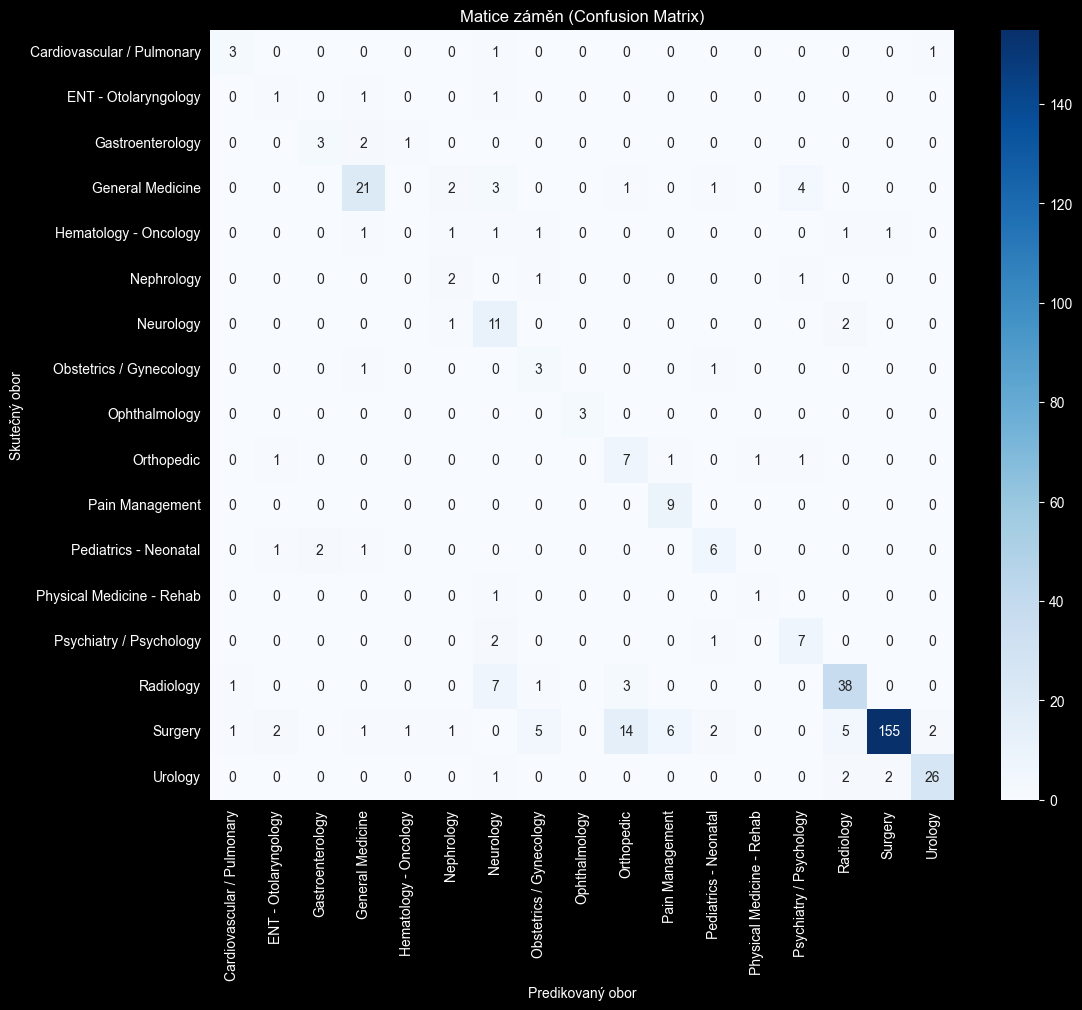

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Vytvoření matice
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))

# Vykreslení pomocí Seaborn
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clf.classes_,
            yticklabels=clf.classes_)

plt.title('Matice záměn (Confusion Matrix)')
plt.xlabel('Predikovaný obor')
plt.ylabel('Skutečný obor')
plt.xticks(rotation=90)
plt.show()

In [51]:
from deep_translator import GoogleTranslator
from geopy.distance import geodesic

def preloz_do_en(text):
    """Přeloží český symptom do angličtiny pro potřeby AI."""
    try:
        return GoogleTranslator(source='cs', target='en').translate(text)
    except:
        return text

def spocitej_km(moje_gps, gps_doktora):
    """Vypočítá vzdálenost pro GPS formát oddělený mezerou."""
    if pd.isna(gps_doktora) or str(gps_doktora).strip() == "":
        return 9999.0

    try:
        # Rozdělíme řetězec podle mezery (strip odstraní případné mezery na krajích)
        parts = str(gps_doktora).strip().split()

        if len(parts) != 2:
            return 9999.0

        lat = float(parts[0])
        lon = float(parts[1])

        return geodesic(moje_gps, (lat, lon)).km
    except:
        return 9999.0

In [45]:
def ziskej_obory_podle_ai(text_en, threshold=0.3):
    """Vrátí seznam českých oborů, které AI doporučuje."""
    vektor = embedder.encode([text_en])
    probs = clf.predict_proba(vektor)[0]

    indices = np.where(probs >= threshold)[0]
    if len(indices) == 0:
        return []

    # Seřazení a vytažení českých názvů z mappingu
    labels = [clf.classes_[i] for i in indices[np.argsort(probs[indices])[::-1]]]

    cz_specialties = []
    for label in labels:
        cz_specialties.extend(clean_mapping.get(label, []))

    return list(set(cz_specialties)), labels[0] # Vrací seznam oborů a nejlepší anglický label

In [59]:
def symptolink_engine(text_cz, moje_poloha, top_n=5):
    # 1. Krok: Překlad
    text_en = preloz_do_en(text_cz)

    # 2. Krok: AI analýza
    cz_obory, top_label = ziskej_obory_podle_ai(text_en)

    if not cz_obory:
        return "AI si není jistá, zkuste jiný popis."

    # 3. Krok: Filtrace v registru
    pattern = '|'.join(cz_obory)
    mask = df_registr['OborPece_List'].str.contains(pattern, case=False, na=False)
    vysledky = df_registr[mask].copy()

    # 4. Krok: Výpočet vzdálenosti
    vysledky['vzdalenost_km'] = vysledky['GPS'].apply(lambda x: spocitej_km(moje_poloha, x))

    # 5. Krok: FINÁLNÍ FILTRACE DUPLICIT A ŘAZENÍ
    # Nejdříve seřadíme podle vzdálenosti, aby při mazání duplicit zůstal ten nejbližší záznam
    vysledky = vysledky.sort_values('vzdalenost_km')

    # ODSTRANĚNÍ DUPLICIT: Pokud má klinika/doktor stejný název, necháme jen ten první (nejbližší)
    vysledky = vysledky.drop_duplicates(subset=['NazevCely'], keep='first')

    print(f"--- SYMPTOLINK ENGINE ---")
    print(f"Vstup: {text_cz} | AI odhad: {top_label}")
    print(f"Hledáno v ČR: {len(vysledky)} unikátních lékařů/klinik.")

    return vysledky[['NazevCely', 'Obec', 'Ulice', 'vzdalenost_km']].head(top_n)

# --- FINÁLNÍ TEST ---
moje_poloha = (50.08189, 14.42686) # Praha
symptolink_engine("Mám hrozný kašel a nemůžu dýchat", moje_poloha)

--- SYMPTOLINK ENGINE ---
Vstup: Mám hrozný kašel a nemůžu dýchat | AI odhad: ENT - Otolaryngology
Hledáno v ČR: 7955 unikátních lékařů/klinik.


,NazevCely,Obec,Ulice,vzdalenost_km
28574,Promedis s.r.o.,Praha 1,Vodičkova,0.094875
17785,Medicare4u s.r.o.,Praha 1,Vodičkova,0.095632
17666,"Kardiologie Vinohrady, s.r.o.",Praha 1,Vodičkova,0.095632
7540,Clinic4u s.r.o.,Praha 1,Vodičkova,0.095632
14257,"BOMTON CLINIC, s.r.o.",Praha 1,Václavské náměstí,0.113580


In [53]:
test_gps_z_tabulky = df_registr['GPS'].iloc[0] # Vezmeme první GPS z registru
test_moje = (50.08, 14.42)

vysledek = spocitej_km(test_moje, test_gps_z_tabulky)

print(f"Testovací GPS z registru: '{test_gps_z_tabulky}'")
print(f"Moje poloha: {test_moje}")
print(f"Výsledek funkce: {vysledek} km")

if vysledek == 9999.0:
    print("Funkce stále vrací chybu. GPS formát v registru nesedí s výpočtem.")
else:
    print("Funkce funguje správně!")

Testovací GPS z registru: '49.84903867677 14.702378106302'
Moje poloha: (50.08, 14.42)
Výsledek funkce: 32.71728293829392 km
Funkce funguje správně!


In [60]:
import joblib
import os

# 1. Kontrola, zda složka src_model existuje (pokud ne, vytvoří se)
os.makedirs('../src_model', exist_ok=True)

# 2. Uložení natrénovaného AI modelu (tvá Logistic Regression)
joblib.dump(clf, '../src_model/medical_classifier.joblib')

# 3. Uložení metadat - model potřebuje vědět, jaké má třídy a jaký je tvůj český mapping
metadata = {
    'classes': clf.classes_,
    'clean_mapping': clean_mapping
}
joblib.dump(metadata, '../src_model/model_metadata.joblib')

print("Úspěch! Model a slovníky byly uloženy do složky 'src_model'.")

Úspěch! Model a slovníky byly uloženy do složky 'src_model'.
